<a href="https://colab.research.google.com/github/nilsberzins/stat-405-final/blob/main/EDA405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Connect to Database and pull data

In [111]:
!pip install pymysql --quiet
!pip install boto3 --quiet
!pip install sqlalchemy --quiet
!pip install python-dotenv --quiet
!pip install prophet --quiet
!pip install xgboost --quiet

In [112]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

In [113]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [114]:
import pymysql
import sys
import boto3
import os
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
connection = pymysql.connect(
    host=os.getenv("AWS_DATABASE_ENDPOINT"),
    user=os.getenv("AWS_USER"),
    port=int(os.getenv("AWS_PORT")),
    passwd=os.getenv("AWS_PASSWORD"),
    database=os.getenv("AWS_DBNAME")
)

In [116]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

CA_funding_dataset
CSU_Data_2010
CSU_Data_2011
CSU_Data_2012
CSU_Data_2013
CSU_Data_2014
CSU_Data_2015
CSU_Data_2016
CSU_Data_2017
CSU_salaries_data
Inflation_data
SuperBowl_coinTosses
UCOP_Data_2010
UCOP_Data_2011
UCOP_Data_2012
UCOP_Data_2013
UCOP_Data_2014
UCOP_Data_2015
UCOP_Data_2016
UCOP_Data_2017
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


**Load Data from AWS**

In [117]:
funding_df = pd.read_sql("SELECT * FROM CA_funding_dataset", con=connection)
funding_df

<ipython-input-117-a2cf812b747a>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  funding_df = pd.read_sql("SELECT * FROM CA_funding_dataset", con=connection)


,row_names,FY,State,Census Region,Regional Compact,% Tax Appropriations,% Local,% Non-Tax,% Endowment,% Other Support,...,% State Operating for Four Year Institutions,% Local Funding for Two Year Institutions,% Local Funding for Four Year Institutions,% RAM for Four Year Institutions,% State Public Financial Aid for Two Year Institutions,% State Public Financial Aid for Four Year Institutions,Education Appropriation per FTE for Two Year Institutions,Education Appropriation per FTE for Four Year Institutions,Net Tuition per FTE for Two Year Institutions,Net Tuition per FTE for Four Year Institutions
0,1,2024.0,California,West,WICHE,80.9,16.9,2.3,0.0,0.0,...,74.2,35.9,0.0,11.5,5.5,14.3,13381.0,14395.0,743.0,7321.0
1,2,2023.0,California,West,WICHE,80.7,16.7,2.6,0.0,0.0,...,72.8,34.6,0.0,13.8,5.6,13.5,14445.0,13669.0,813.0,7341.0
2,3,2022.0,California,West,WICHE,82.1,15.4,2.5,0.0,0.0,...,72.6,29.5,0.0,13.1,4.8,14.3,16038.0,12470.0,797.0,7165.0
3,4,2021.0,California,West,WICHE,80.7,17.0,2.3,0.0,0.0,...,73.2,31.3,0.0,9.6,6.1,17.2,13235.0,10763.0,792.0,7002.0
4,5,2020.0,California,West,WICHE,80.9,17.0,2.1,0.0,0.0,...,78.0,33.2,0.0,12.0,7.4,10.0,10711.0,10831.0,732.0,8188.0
5,6,2019.0,California,West,WICHE,81.2,16.7,2.1,0.0,0.0,...,78.6,31.2,0.0,11.9,7.6,9.5,10802.0,10388.0,768.0,8069.0
6,7,2018.0,California,West,WICHE,79.7,17.2,3.1,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2017.0,California,West,WICHE,80.1,17.7,2.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2016.0,California,West,WICHE,81.0,16.8,2.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2015.0,California,West,WICHE,82.0,15.8,2.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
funding_df['% Public Financial Aid']

,% Public Financial Aid
0,9.0
1,8.7
2,8.5
3,10.4
4,8.2
5,8.1
6,8.7
7,9.2
8,11.3
9,13.4


In [120]:
inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)
inflation_df.head()

<ipython-input-120-32a92bd7d88e>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  inflation_df = pd.read_sql("SELECT * FROM Inflation_data", con=connection)


,row_names,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2
0,1,2000.0,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174.0,174.1,174.0,170.8,173.6
1,2,2001.0,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5
2,3,2002.0,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9
3,4,2003.0,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185.0,184.5,184.3,183.3,184.6
4,5,2004.0,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2


In [121]:
# add a column which is the annual average CPI
inflation_df['annual_cpi'] = inflation_df.loc[:, 'Jan':'Dec'].mean(axis=1)
inflation_df.head()

,row_names,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2,annual_cpi
0,1,2000.0,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174.0,174.1,174.0,170.8,173.6,172.200000
1,2,2001.0,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5,177.066667
2,3,2002.0,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9,179.875000
3,4,2003.0,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185.0,184.5,184.3,183.3,184.6,183.958333
4,5,2004.0,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2,188.883333


In [122]:
years = range(2010, 2017)
dfs = []

for year in years:
    query = f"""
    SELECT *
    FROM `CSU_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)
    dfs.append(df)

full_data_csu = pd.concat(dfs, ignore_index=True)
full_data_csu.head()

<ipython-input-122-5d4bcbe494cc>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


,row_names,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,...,HealthDentalVision,TotalRetirementAndHealthContribution,PensionFormula,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType
0,1,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,6482.16,14798.44,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
1,2,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16470.84,24556.27,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
2,3,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16470.84,25325.06,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
3,4,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,6551.16,14752.03,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None
4,5,2010,California State University,Chancellor's Office,None,"Accountant I, Range 1",None,None,,43392.0,...,16018.80,23644.67,2.00% @ 55,http://www.calstate.edu/HRS/,None,07/01/2014,Los Angeles,None,None,None


In [123]:
years = range(2010, 2024)
dfs = []

for year in years:
    query = f"""
    SELECT '{year}' AS year, location, title, `regular.pay`
    FROM `UCOP_Data_{year}`
    """
    df = pd.read_sql(query, con=connection)

    if year in [2013, 2014, 2015]:
        df = df.applymap(lambda x: x.strip("'") if isinstance(x, str) else x)

    df["year"] = df["year"].astype(int)
    df["regular.pay"] = pd.to_numeric(df["regular.pay"], errors='coerce')

    dfs.append(df)

full_data = pd.concat(dfs, ignore_index=True)
full_data.head()

<ipython-input-123-a6df2b0e4706>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-123-a6df2b0e4706>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-123-a6df2b0e4706>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)
<ipython-input-123-a6df2b0e4706>:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connectio

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
1,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,5369.42
2,2010,Berkeley,TEACHING ASSISTANT - GSHIP,4802.00
3,2010,Berkeley,GRAD STDNT RES- NO REMISSION,3409.01
4,2010,Berkeley,GRAD STDNT RES-FULL FEE REM,11673.90


In [125]:
full_data = full_data[full_data["regular.pay"]>0] # filter out rows with regular.pay = 0 (possibly pay coming from different sources?)

In [126]:
full_data = full_data.dropna()

In [127]:
full_data["location"].unique()

array(['Santa Cruz', 'Berkeley', 'DANR', 'Davis', 'Irvine', 'Los Angeles',
       'Merced', 'Riverside', 'San Diego', 'San Francisco',
       'Santa Barbara', 'UCOP', 'ASUCLA', 'Hastings College Of Law',
       'Hastings'], dtype=object)

In [128]:
to_drop = ["San Francisco", "UCOP", "DANR", "Hastings", "Hastings College Of Law", "ASUCLA"]
full_data = full_data[~full_data["location"].isin(to_drop)]

In [129]:
pattern = r"""(?ix)                     # (?i)=ignore-case  (?x)=verbose mode
    \b(?:                               # word-start, then one of…
        prof(?:essors?\b|\.?\b)         #  "professor" / "professors" / "prof" / "prof."
      | lect(?:urer?s?\b|\b)            #  "lecturer(s)" / "lect"
    )
"""

filtered = full_data[full_data['title'].str.contains(pattern, regex=True, na=False)]


In [130]:
filtered = filtered[~(filtered["title"].str.contains("SUMMER"))]

In [131]:
filtered.head()

,year,location,title,regular.pay
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78


In [132]:
def title_assign(x):
    if "PROFL" in x or "PROFESSIONAL" in x:
        return "OTHER"
    elif "VST" in x and "ASST" in x:
        return "VST ASST"
    elif "VST" in x and "ASSOC" in x:
        return "VST ASSOC"
    elif "VST" in x:
        return "VST PROF"
    elif "ADJ" in x and "ASST" in x:
        return "ADJ ASST"
    elif ("ASOC" in x or "ASSOC" in x) and "ADJ" in x:
        return "ADJ ASOC"
    elif "ADJ" in x:
        return "ADJ PROF"
    elif ("ASST" in x or "ASSIST" in x) and "PROF" in x:
        return "ASST PROF"
    elif "ASSOC" in x and "PROF" in x:
        return "ASSOC PROF"
    elif "PROF" in x:
        return "PROF"
    elif "SR" in x and "LECT" in x:
        return "SR LECT"
    elif "LECT" in x:
        return "LECT"
    else:
        return "OTHER"

In [133]:
filtered['prof_rank'] = (
    filtered['title']
        .str.upper()
        .fillna('')
        .apply(title_assign)
)

filtered['year'] = filtered['year'].astype(int)


filtered.head()


,year,location,title,regular.pay,prof_rank
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF
20,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT
94,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT
175,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT
178,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT


In [134]:
filtered["prof_rank"].value_counts()

,count
prof_rank,
PROF,99796
LECT,66045
ASST PROF,45946
ASSOC PROF,40005
ADJ ASST,4933
ADJ PROF,4025
ADJ ASOC,2745
SR LECT,2209
VST ASST,529


In [135]:
avg_salary = (
    filtered
      .groupby(['prof_rank', 'location'], as_index=False)
      .agg(avg_regular_pay=('regular.pay', 'mean'))
)

avg_salary


,prof_rank,location,avg_regular_pay
0,ADJ ASOC,Berkeley,76209.988050
1,ADJ ASOC,Davis,78069.147082
2,ADJ ASOC,Irvine,75783.453233
3,ADJ ASOC,Los Angeles,81951.866162
4,ADJ ASOC,Riverside,83422.896552
...,...,...,...
90,VST PROF,Los Angeles,26274.428080
91,VST PROF,Riverside,14328.400000
92,VST PROF,San Diego,26011.854286
93,VST PROF,Santa Barbara,24105.281000


In [137]:
# some EDAs for filtered, existing features
# year: 2010-2023, some imbalance in representation for each year but not too bad
filtered['year'].value_counts()

,count
year,
2023,22302
2022,22244
2021,21958
2018,20801
2019,20664
2017,20265
2016,19662
2015,18743
2014,18193


In [139]:
# locations: LA, SD, Davis, Berkeley, Irvine, SB, Riverside, SC, Merced
# some imbalance in counts especially Merced is lower than the rest
filtered['location'].value_counts()

,count
location,
Los Angeles,66194
San Diego,41552
Davis,39136
Berkeley,37149
Irvine,31949
Santa Barbara,17362
Riverside,15044
Santa Cruz,12853
Merced,5569


In [155]:
filtered[filtered['regular.pay'] < 200]

,year,location,title,regular.pay,prof_rank
157325,2010,San Diego,LECTURER-MISC/PART-TIME,179.15,LECT
185135,2010,Berkeley,ASSOC ADJUNCT PROFESSOR - AY,147.63,ADJ ASOC
199218,2010,Davis,PROF IN RES-MEDCOMP-A,120.00,PROF
667628,2012,Merced,LECT-AY-1/9,109.83,LECT
854391,2013,Santa Cruz,LECT-MISCELLANEOUS/PART TIME,135.00,LECT
1123751,2014,Santa Cruz,LECT-MISCELLANEOUS/PART TIME,81.00,LECT
1148382,2014,Berkeley,LECT-AY,177.00,LECT
1159853,2014,Los Angeles,PROFESSOR-FISCAL YR-RECALLED,2.00,PROF
1228053,2014,San Diego,HS ASST CLIN PROF-HCOMP,100.00,ASST PROF
1262701,2014,Los Angeles,PROF-HCOMP,103.00,PROF


<Axes: xlabel='regular.pay', ylabel='Count'>

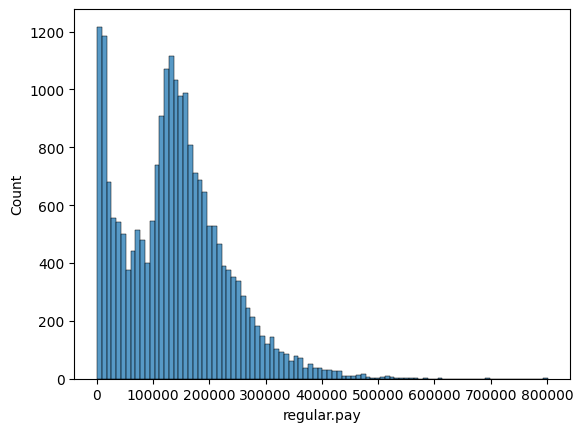

In [156]:
# pay distribution for all faculty in year 2023, with a lot of professors being under $1000 (why?)
sns.histplot(filtered[filtered['year'] == 2023], x='regular.pay')

adding more features

In [157]:
inflation_df['Year'] = inflation_df['Year'].astype(int)
cpi_df = inflation_df[['Year', 'annual_cpi']]
cpi_df.columns = ['year', 'annual_cpi']
cpi_df.head()

,year,annual_cpi
0,2000,172.200000
1,2001,177.066667
2,2002,179.875000
3,2003,183.958333
4,2004,188.883333


<Axes: xlabel='year', ylabel='annual_cpi'>

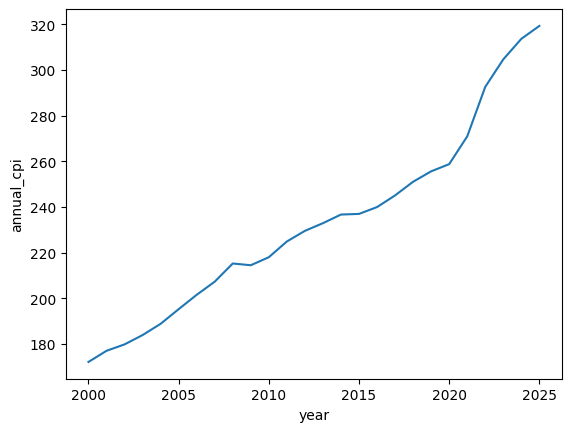

In [160]:
sns.lineplot(data=cpi_df, x='year', y='annual_cpi')
# INTERPRETATION TODO

In [ ]:
# add one feature - annual cpi for every year
uc_df_enhanced = filtered.merge(cpi_df, on='year')
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF,218.055500
1,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT,218.055500
2,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT,218.055500
3,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT,218.055500
4,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT,218.055500
...,...,...,...,...,...,...
266803,2023,San Diego,PROF IN RES-HCOMP,30330.00,PROF,304.701583
266804,2023,Merced,ASST PROF-AY,104433.00,ASST PROF,304.701583
266805,2023,Santa Cruz,ASST PROF-AY,98567.00,ASST PROF,304.701583
266806,2023,Berkeley,LECT-AY-CONTINUING,92865.00,LECT,304.701583


In [ ]:
enroll_df = pd.read_csv('/content/drive/MyDrive/Enrollment_levels.csv')
enroll_df.columns.values[0:2] = ['level', 'location']

enroll_long = enroll_df.melt(id_vars=['level', 'location'],
                             var_name='year',
                             value_name='student_enrollment')
enroll_long = enroll_long.dropna()

enroll_long['student_enrollment'] = enroll_long['student_enrollment'].str.replace(',', '')
enroll_long['student_enrollment'] = enroll_long['student_enrollment'].astype(int)
enroll_long['year'] = enroll_long['year'].astype(int)
enroll_long['location'] = enroll_long['location'].str.strip()

enroll_summary = enroll_long.groupby(['location', 'year'], as_index=False)['student_enrollment'].sum()
enroll_summary.head()



,location,year,student_enrollment
0,Berkeley,2010,35833
1,Berkeley,2011,36137
2,Berkeley,2012,35893
3,Berkeley,2013,36198
4,Berkeley,2014,37565


In [ ]:
# add another feature - enrollment number unique to the combo of year & location
uc_df_enhanced = uc_df_enhanced.merge(enroll_summary, on=['year', 'location'])
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi,student_enrollment
0,2010,Santa Cruz,ASSISTANT PROFESSOR-ACAD YR,69999.96,ASST PROF,218.055500,17187
1,2010,Berkeley,LECTURER - ACADEMIC YEAR,25454.75,LECT,218.055500,35833
2,2010,Berkeley,LECTURER - ACADEMIC YEAR,29248.46,LECT,218.055500,35833
3,2010,Berkeley,LECTURER - ACADEMIC YEAR,27058.69,LECT,218.055500,35833
4,2010,Berkeley,LECTURER - ACADEMIC YEAR,28679.78,LECT,218.055500,35833
...,...,...,...,...,...,...,...
266803,2023,San Diego,PROF IN RES-HCOMP,30330.00,PROF,304.701583,42376
266804,2023,Merced,ASST PROF-AY,104433.00,ASST PROF,304.701583,9147
266805,2023,Santa Cruz,ASST PROF-AY,98567.00,ASST PROF,304.701583,19764
266806,2023,Berkeley,LECT-AY-CONTINUING,92865.00,LECT,304.701583,45699


some plots

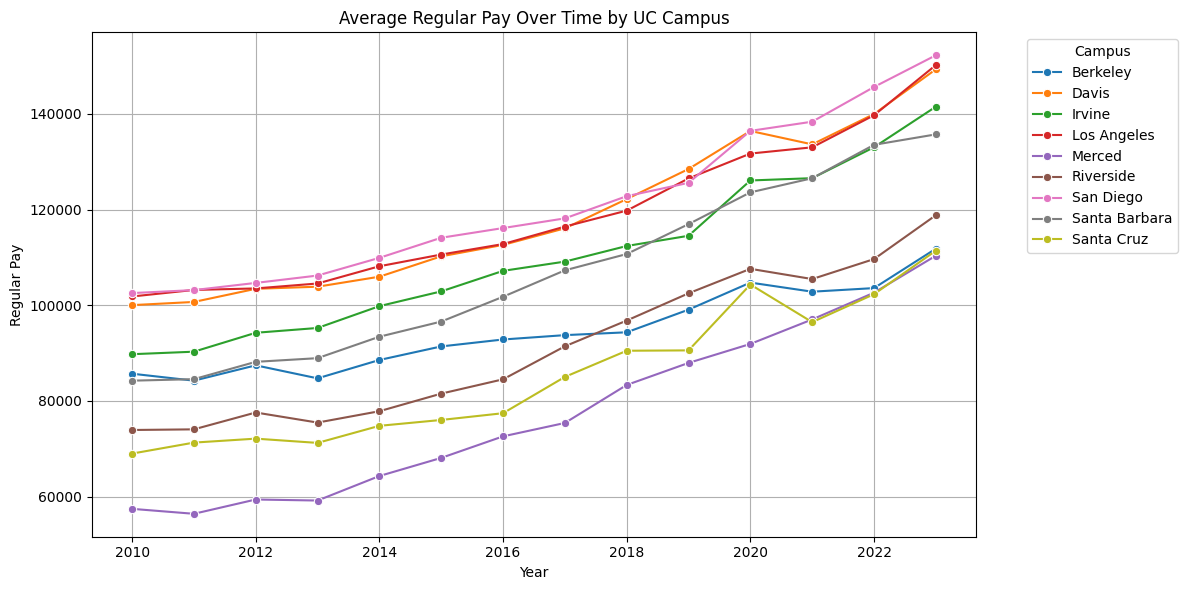

In [ ]:
#time trend analysis plot by campus
avg_by_campus = filtered.groupby(['year', 'location'])['regular.pay'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_by_campus, x='year', y='regular.pay', hue='location', marker="o")

plt.title("Average Regular Pay Over Time by UC Campus")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.legend(title='Campus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

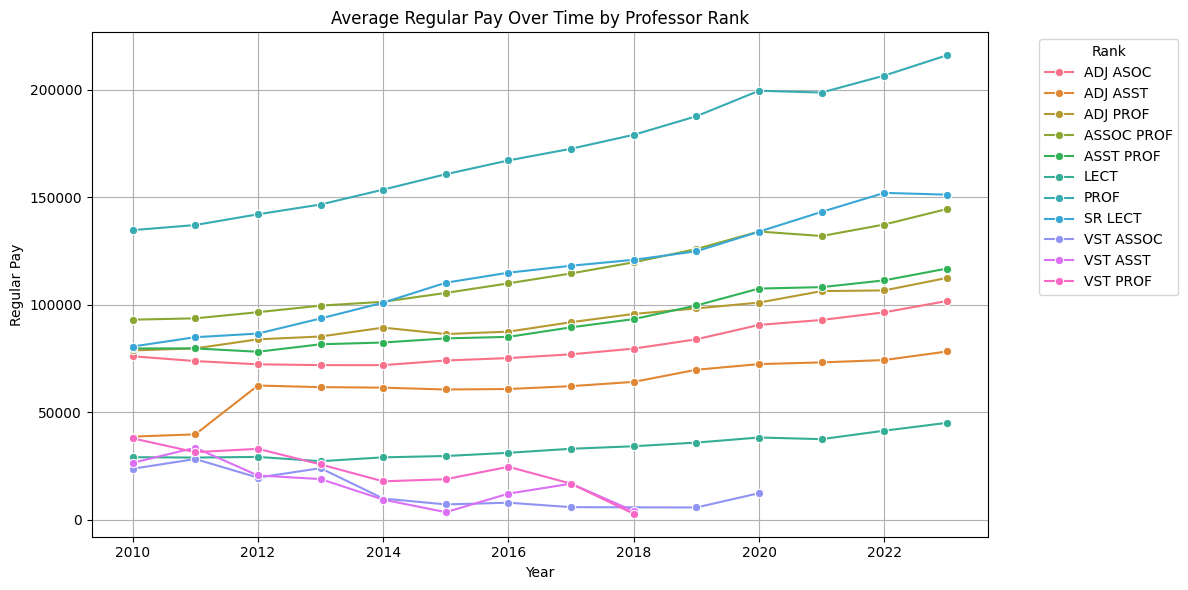

In [ ]:
# By Rank
avg_rank = filtered.groupby(['year', 'prof_rank'])['regular.pay'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_rank , x='year', y='regular.pay', hue='prof_rank', marker="o")

plt.title("Average Regular Pay Over Time by Professor Rank")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.legend(title='Rank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
#want to see if there are disparities
summary = filtered.groupby(['year', 'prof_rank'])['regular.pay'].agg(['count', 'mean', 'median']).reset_index()
summary.head()


,year,prof_rank,count,mean,median
0,2010,ADJ ASOC,186,76070.913118,85075.035
1,2010,ADJ ASST,148,38714.420000,30600.000
2,2010,ADJ PROF,450,78779.265222,80298.630
3,2010,ASSOC PROF,2535,93071.872789,88482.990
4,2010,ASST PROF,2589,79703.768127,79100.040


***Statistical Analysis***

**2 Sample T-Test**

assumptions for 2-sample t-test

Whether the two samples data groups are independent.

Whether the data elements in respective groups follow any normal distribution.

Whether the given two samples have similar variances. This assumption is also known as the homogeneity assumption.

<Axes: xlabel='regular.pay', ylabel='Count'>

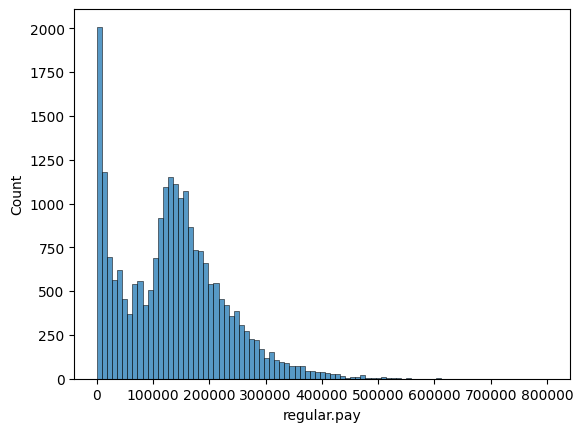

In [ ]:
sns.histplot(filtered[filtered['year'] == 2023], x='regular.pay')

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-34-60d9dbf0d58e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hist_data['regular.pay'] = np.log(hist_data['regular.pay'])


<Axes: xlabel='regular.pay', ylabel='Count'>

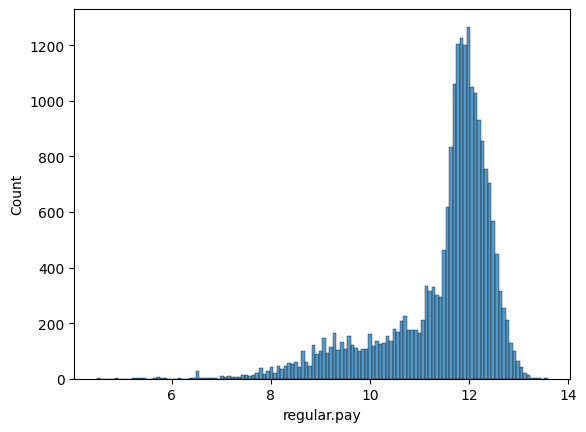

In [ ]:
# check assumptions
# visualize spread of salaries for the year 2023, log transform makes it normal ish

hist_data = filtered[filtered['year'] == 2023]
hist_data['regular.pay'] = np.log(hist_data['regular.pay'])
sns.histplot(hist_data, x='regular.pay')

In [ ]:
# determine variance
hist_data['regular.pay'].value_counts()
filtered['regular.pay'].value_counts()
# print(np.var(hist_data['regular.pay']))

,count
regular.pay,
0.0,5287
6202.0,81
132183.0,78
140300.0,77
6021.0,74
...,...
52191.0,1
79412.0,1
35304.0,1


MODELING

**LINEAR REGRESSION**

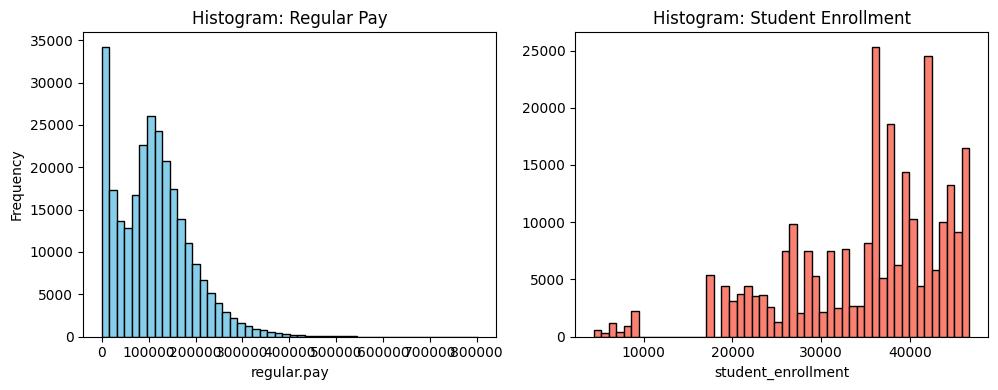

In [ ]:
#checking for normality
# Set figure size
plt.figure(figsize=(15, 4))

# Plot histogram for regular.pay
plt.subplot(1, 3, 1)
plt.hist(uc_df_enhanced['regular.pay'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram: Regular Pay')
plt.xlabel('regular.pay')
plt.ylabel('Frequency')

# Plot histogram for student enrollment
plt.subplot(1, 3, 2)
plt.hist(uc_df_enhanced['student_enrollment'], bins=50, color='salmon', edgecolor='black')
plt.title('Histogram: Student Enrollment')
plt.xlabel('student_enrollment')

plt.tight_layout()
plt.show()


In [ ]:
uc_df_enhanced['log_pay'] = np.log(uc_df_enhanced['regular.pay'])
uc_df_enhanced['log_students'] = np.log1p(uc_df_enhanced['student_enrollment'])

X = uc_df_enhanced[['log_students', 'year', 'prof_rank', 'location', "title"]]
X = pd.get_dummies(X, columns=['prof_rank', 'location', "title"], drop_first=True)

# Define target
y = uc_df_enhanced['log_pay']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² score: 0.7164840056642956
RMSE: 0.6085279735967353


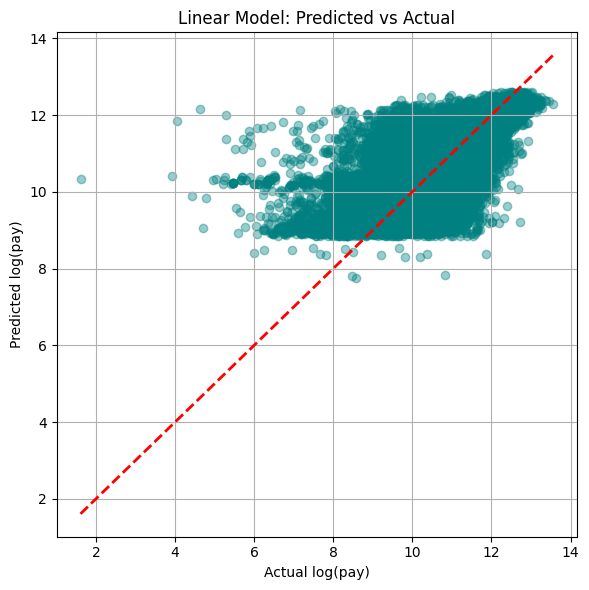

In [ ]:
y_pred = model.predict(X_test)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel('Actual log(pay)')
plt.ylabel('Predicted log(pay)')
plt.title('Linear Model: Predicted vs Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

**clustering**

In [ ]:
uc_df_enhanced

,year,location,title,regular.pay,prof_rank,annual_cpi,enrollees
0,2018,Berkeley,LECT-FY,13721.0,LECT,251.106833,6012
1,2018,Berkeley,LECT-AY-1/10,15384.0,LECT,251.106833,6012
2,2018,Berkeley,LECT-FY,9373.0,LECT,251.106833,6012
3,2018,Berkeley,LECT-AY-1/10,15216.0,LECT,251.106833,6012
4,2018,Berkeley,LECT-AY-1/10,5513.0,LECT,251.106833,6012
...,...,...,...,...,...,...,...
125757,2023,San Diego,PROF IN RES-HCOMP,30330.0,PROF,304.701583,7005
125758,2023,Merced,ASST PROF-AY,104433.0,ASST PROF,304.701583,2416
125759,2023,Santa Cruz,ASST PROF-AY,98567.0,ASST PROF,304.701583,4381
125760,2023,Berkeley,LECT-AY-CONTINUING,92865.0,LECT,304.701583,6641


In [ ]:
# one hot encode variables
cat_vars = pd.get_dummies(uc_df_enhanced[['location', 'prof_rank']], dtype=int)
cat_vars

In [ ]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(uc_df_enhanced)

**RANDOM FOREST**

In [ ]:
#random forest
X = uc_df_enhanced[['log_students', 'year', 'prof_rank', 'location', "title"]]
X = pd.get_dummies(X, columns=['prof_rank', 'location', "title"], drop_first=True)

y = uc_df_enhanced['log_pay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest R² score:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

KeyboardInterrupt: 

<Axes: >

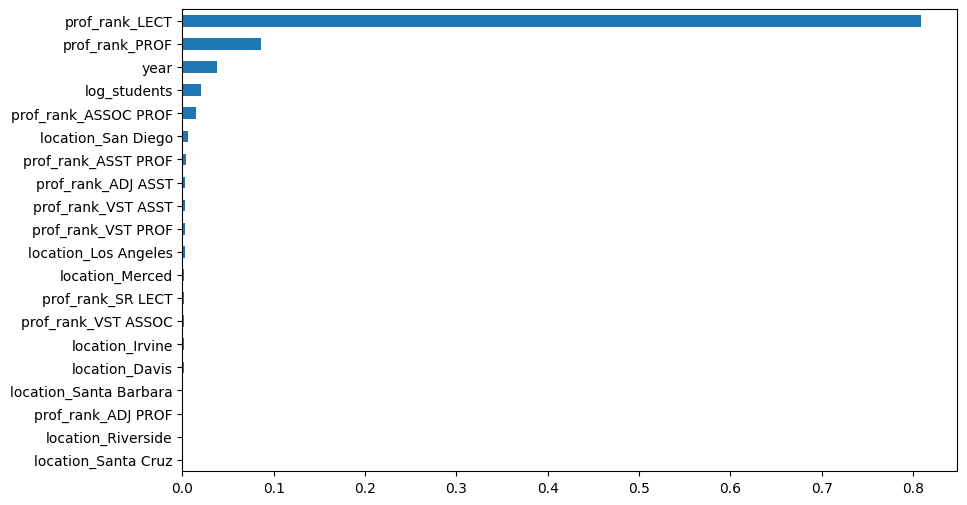

In [ ]:
#checking feature importance
importances = rf_model.feature_importances_
pd.Series(importances, index=X.columns).sort_values().plot(kind='barh', figsize=(10, 6))

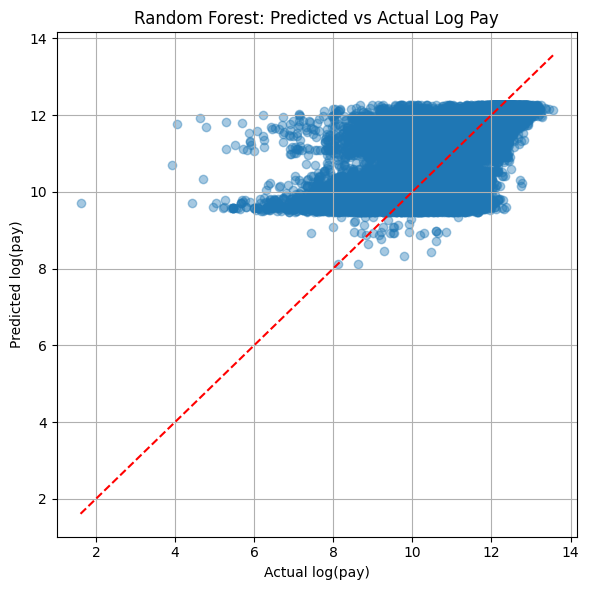

In [ ]:
#prediction plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(pay)')
plt.ylabel('Predicted log(pay)')
plt.title('Random Forest: Predicted vs Actual Log Pay')
plt.grid(True)
plt.tight_layout()
plt.show()


conclusion - prof vs. lecture is a big disparity, title matters most when predicting pay

**XG Boost**

In [ ]:
# Define predictors and target
X = uc_df_enhanced[['log_students', 'year', 'prof_rank', 'location', 'title']]
X = pd.get_dummies(uc_df_enhanced[['log_students', 'year', 'prof_rank', 'location', 'title']],
                   columns=['prof_rank', 'location', 'title'],
                   drop_first=True)


y = uc_df_enhanced['log_pay']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost R²:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost R²: 0.7216194655998882
XGBoost RMSE: 0.602991509692118


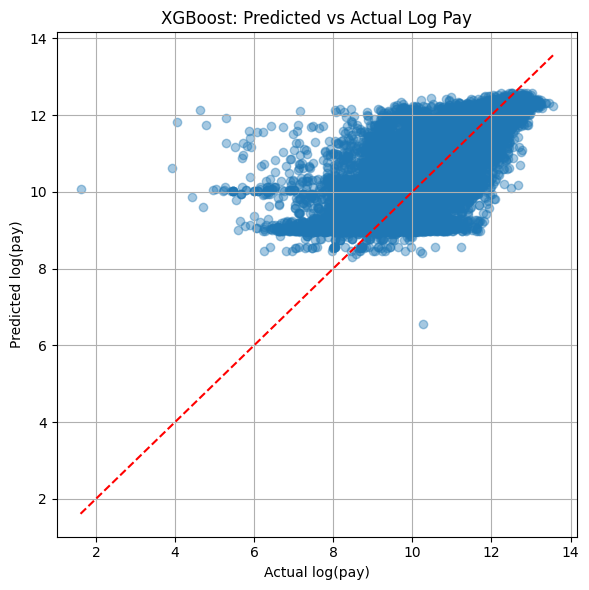

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(pay)')
plt.ylabel('Predicted log(pay)')
plt.title('XGBoost: Predicted vs Actual Log Pay')
plt.grid(True)
plt.tight_layout()
plt.show()

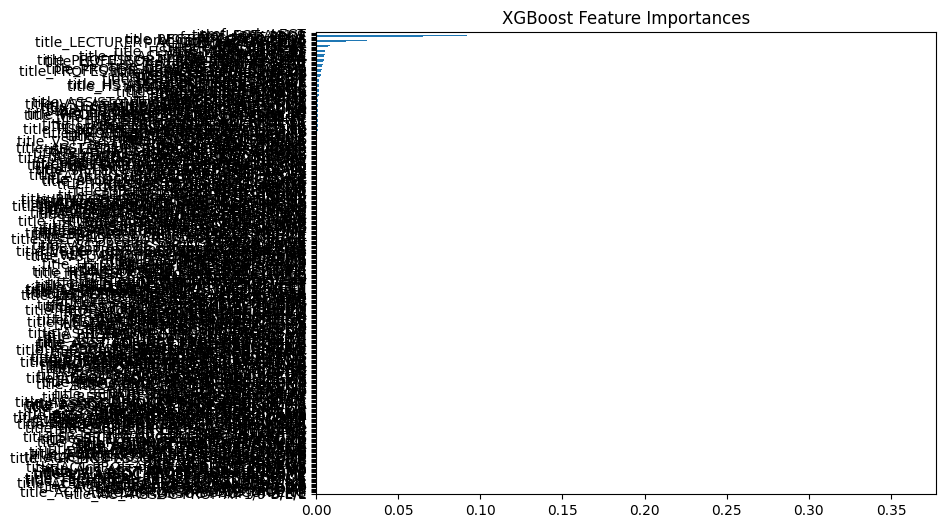

In [ ]:
importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values()
feat_imp.plot(kind='barh', figsize=(8, 6))
plt.title("XGBoost Feature Importances")
plt.show()

**Prophet Forecasting**

In [ ]:
#time series prophet

# Group to get annual UC-wide average pay
df_avg = filtered.groupby('year')['regular.pay'].mean().reset_index()
df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')  # Prophet needs datetime
df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

model = Prophet()
model.fit(df_avg)

# Forecast 5 years into the future
future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/03_998t0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/tf9735iw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29771', 'data', 'file=/tmp/tmplcqx2800/03_998t0.json', 'init=/tmp/tmplcqx2800/tf9735iw.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelx0_xwio7/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

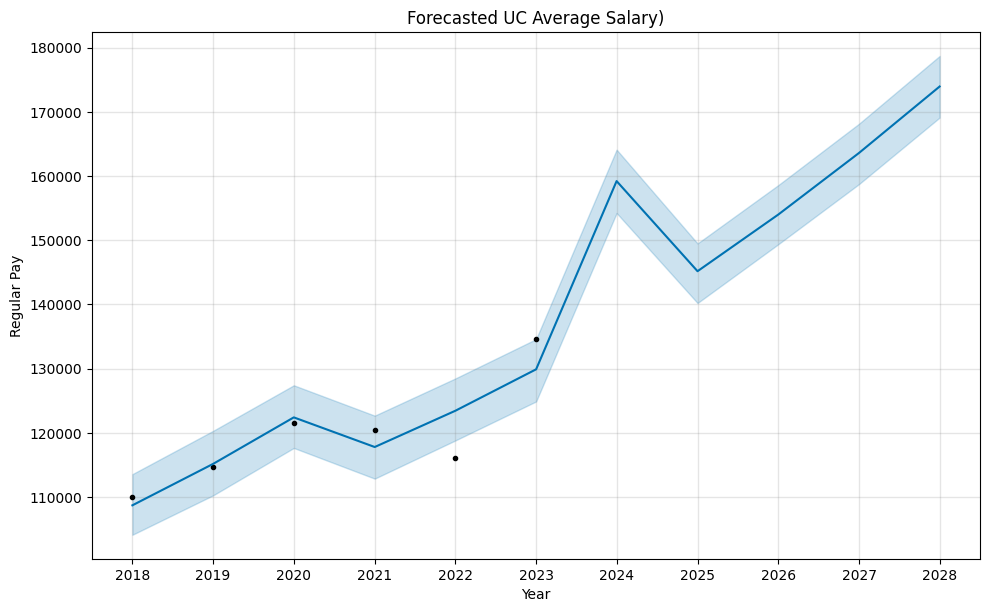

In [ ]:
model.plot(forecast)
plt.title("Forecasted UC Average Salary)")
plt.ylabel("Regular Pay")
plt.xlabel("Year")
plt.grid(True)
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/g9p7xnwe.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/bnrsmxx_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19960', 'data', 'file=/tmp/tmplcqx2800/g9p7xnwe.json', 'init=/tmp/tmplcqx2800/bnrsmxx_.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelif3u5sca/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

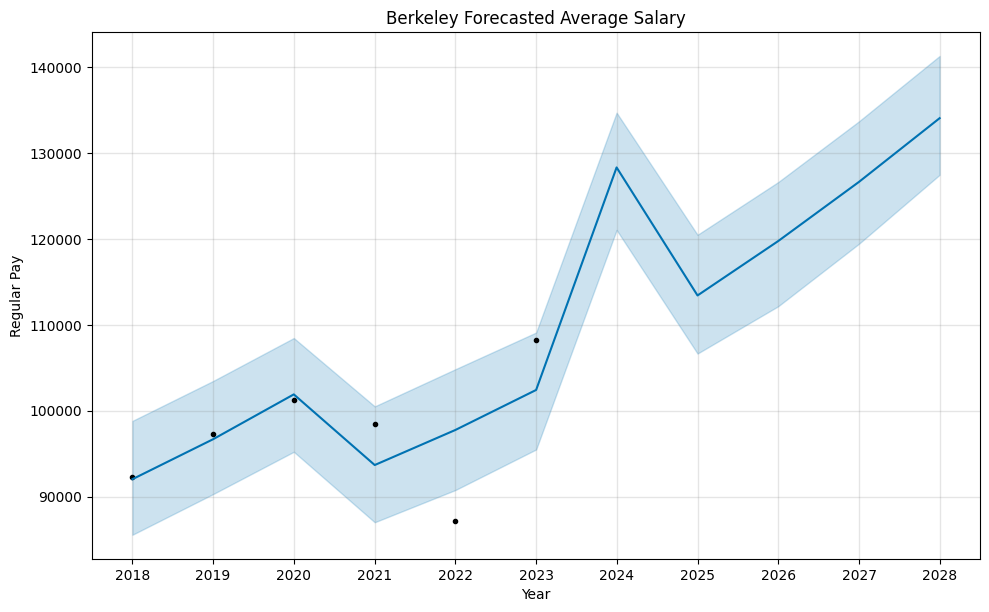

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/gkdv39zh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/0yvrncfw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30214', 'data', 'file=/tmp/tmplcqx2800/gkdv39zh.json', 'init=/tmp/tmplcqx2800/0yvrncfw.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model7zcakcfg/prophet_model-20250607045018.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

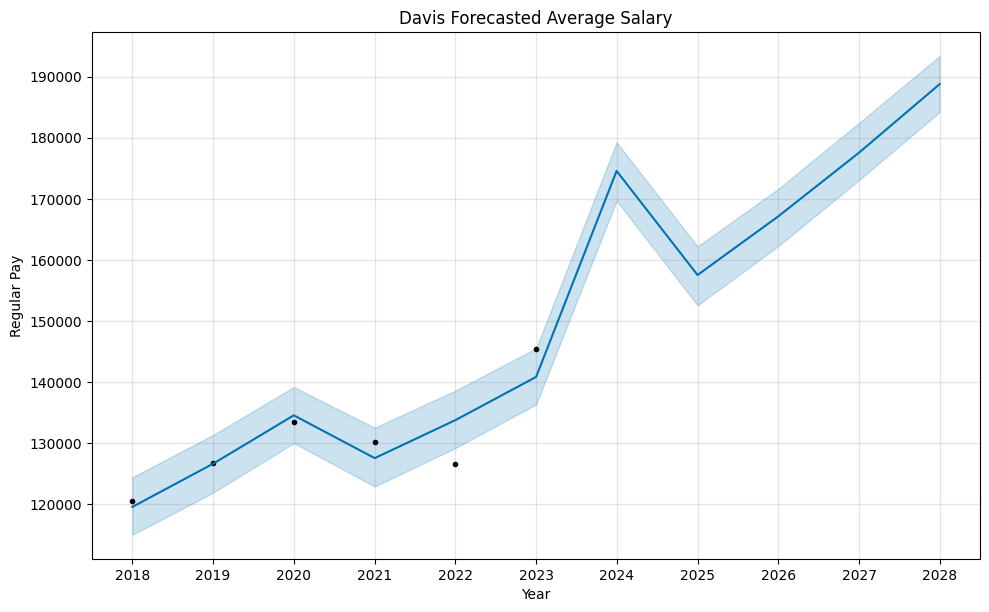

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/w3w3i6d8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/hqd5aig_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24616', 'data', 'file=/tmp/tmplcqx2800/w3w3i6d8.json', 'init=/tmp/tmplcqx2800/hqd5aig_.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelibl5991i/prophet_model-20250607045019.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

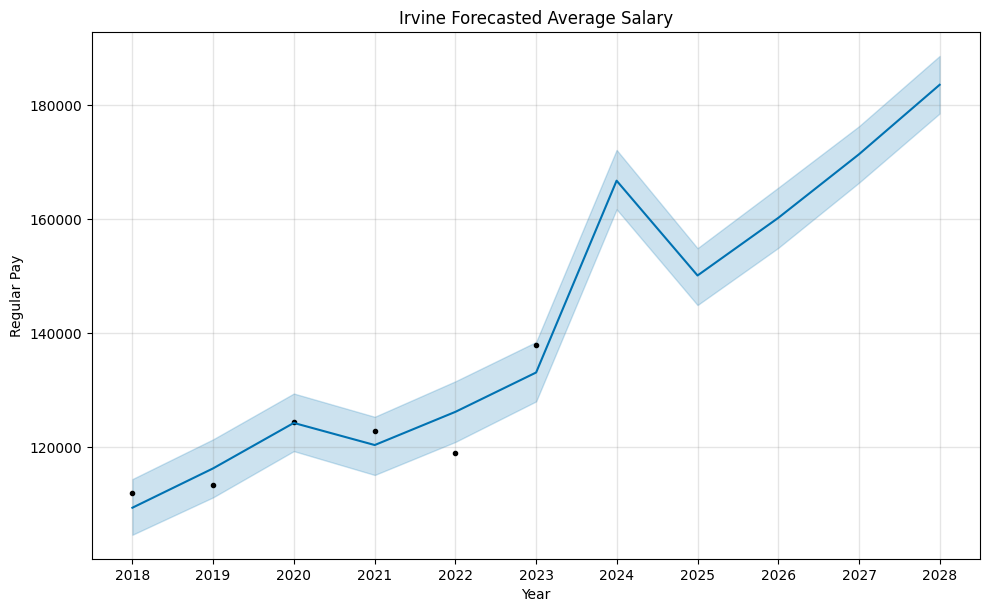

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/jn3ls41y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/5fnp03n6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40266', 'data', 'file=/tmp/tmplcqx2800/jn3ls41y.json', 'init=/tmp/tmplcqx2800/5fnp03n6.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model_wt_sltb/prophet_model-20250607045019.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

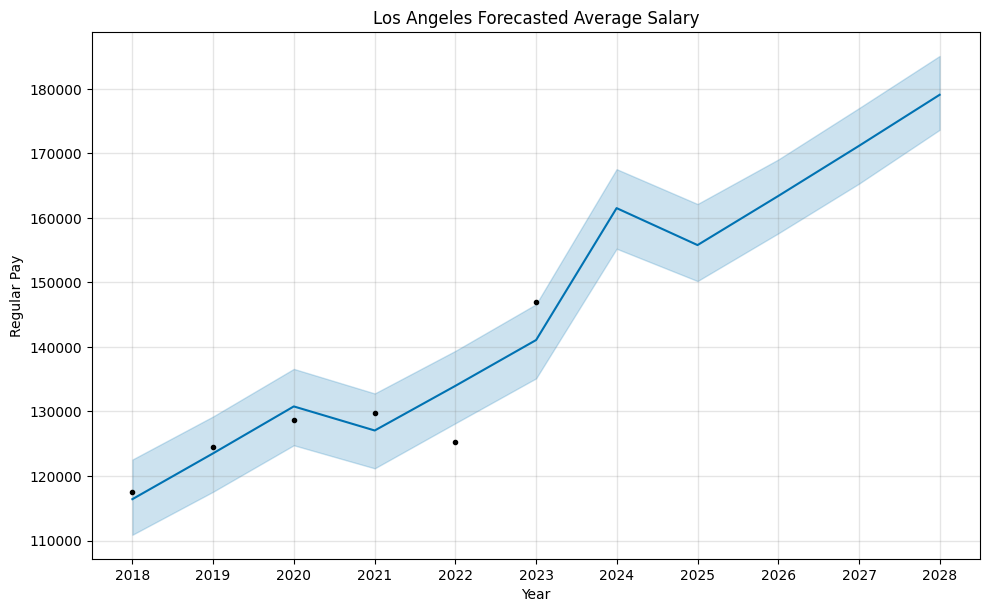

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/qepp3jc2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/mipqhz1l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33332', 'data', 'file=/tmp/tmplcqx2800/qepp3jc2.json', 'init=/tmp/tmplcqx2800/mipqhz1l.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model9q3tzovg/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

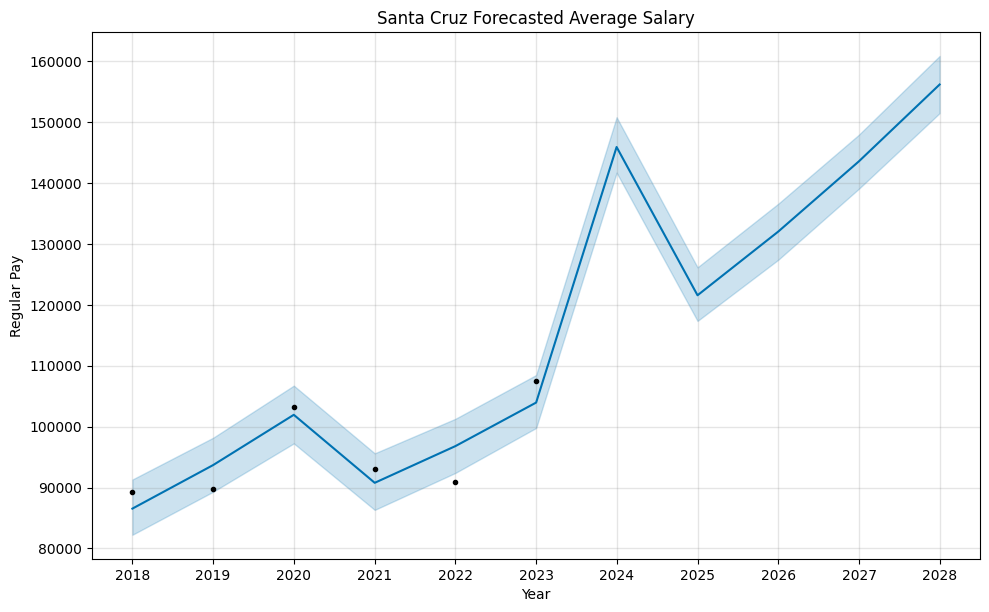

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/t5z8egt0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/7he9_rap.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36290', 'data', 'file=/tmp/tmplcqx2800/t5z8egt0.json', 'init=/tmp/tmplcqx2800/7he9_rap.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model43kf9w33/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

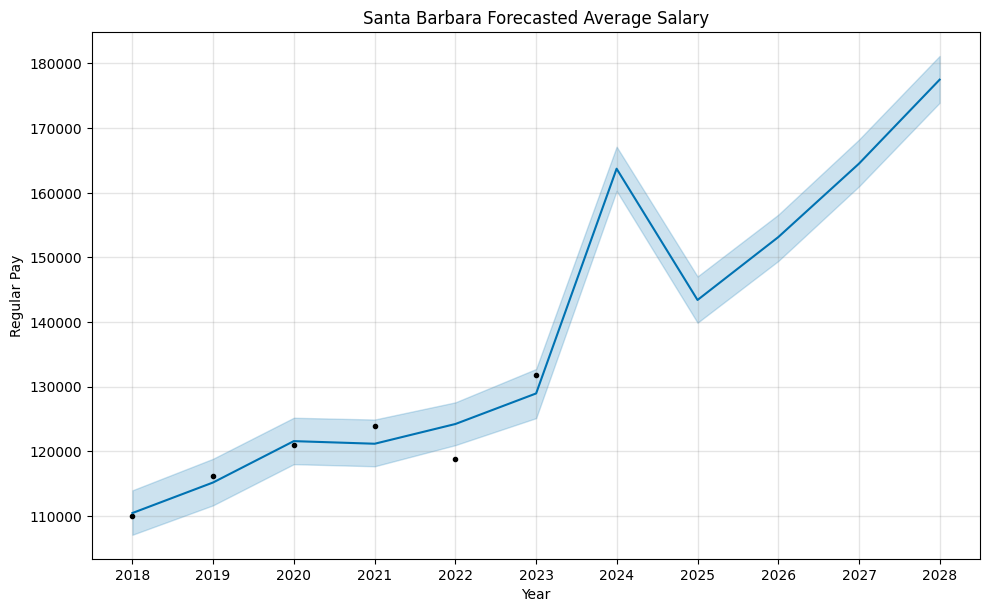

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/ynr791s6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/grn4e0z7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94098', 'data', 'file=/tmp/tmplcqx2800/ynr791s6.json', 'init=/tmp/tmplcqx2800/grn4e0z7.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model1lbaw3rk/prophet_model-20250607045020.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

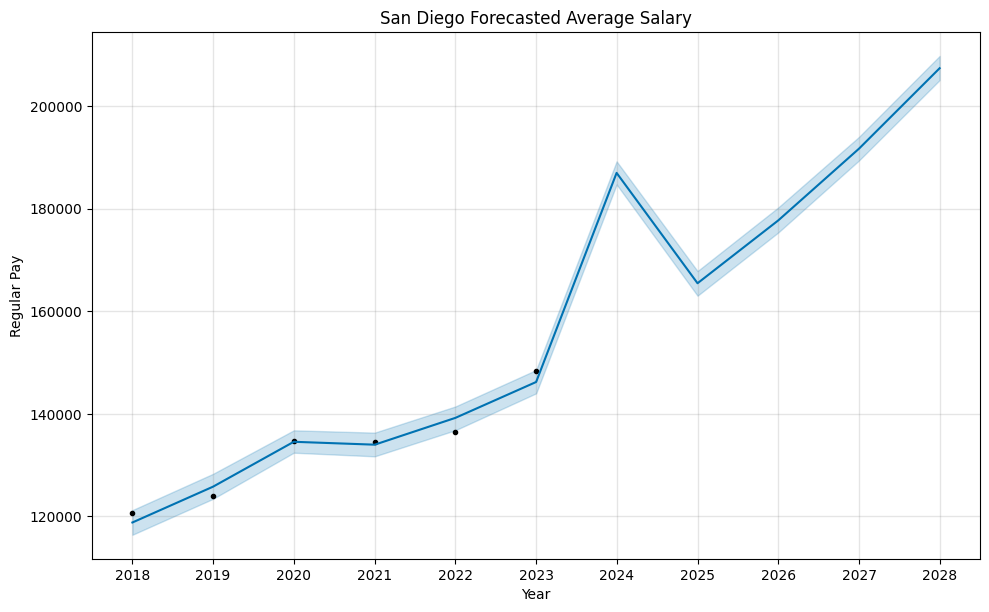

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/6gnupv82.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/3o42dr23.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95168', 'data', 'file=/tmp/tmplcqx2800/6gnupv82.json', 'init=/tmp/tmplcqx2800/3o42dr23.json', 'output', 'file=/tmp/tmplcqx2800/prophet_model4484_t2i/prophet_model-20250607045021.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

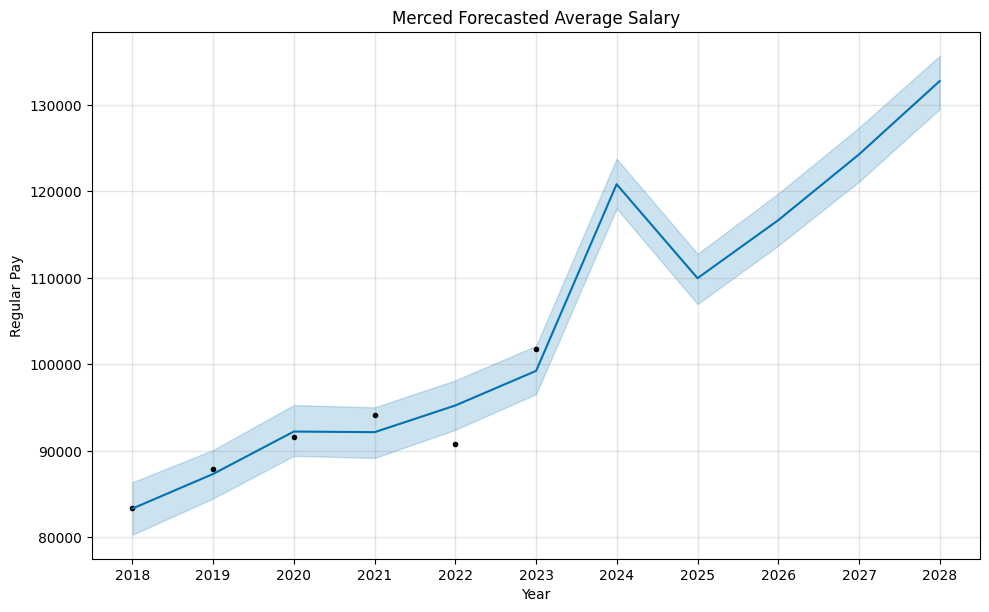

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/jfwfh8e7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplcqx2800/xlpkbu_y.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64424', 'data', 'file=/tmp/tmplcqx2800/jfwfh8e7.json', 'init=/tmp/tmplcqx2800/xlpkbu_y.json', 'output', 'file=/tmp/tmplcqx2800/prophet_modelhq46aa_3/prophet_model-20250607045021.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:50:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:50:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

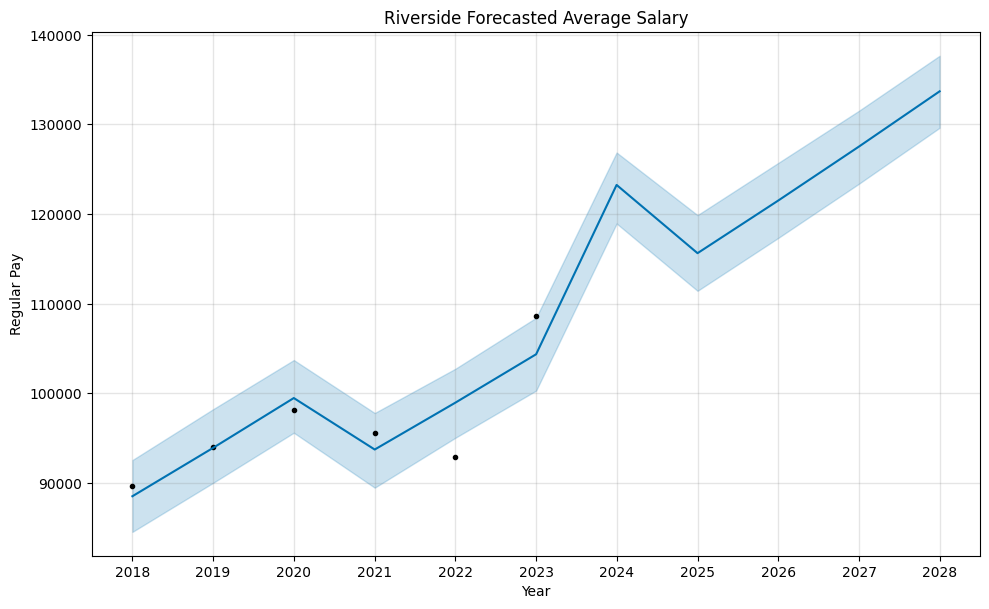

In [ ]:
#campus specific
for campus in filtered['location'].unique():
    df_campus = filtered[filtered['location'] == campus]
    df_avg = df_campus.groupby('year')['regular.pay'].mean().reset_index()
    df_avg['ds'] = pd.to_datetime(df_avg['year'], format='%Y')
    df_avg = df_avg.rename(columns={'regular.pay': 'y'})[['ds', 'y']]

    if len(df_avg) < 5:
        continue  # skip if not enough data

    model = Prophet()
    model.fit(df_avg)

    future = model.make_future_dataframe(periods=5, freq='Y')
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title(f"{campus} Forecasted Average Salary")
    plt.ylabel("Regular Pay")
    plt.xlabel("Year")
    plt.show()
